In [187]:
import glob
import json
import os
import re
import zipfile
import queue
import threading

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pdfplumber
import requests
import hnswlib
from html2text import html2text
from sentence_transformers import SentenceTransformer
from tqdm.notebook import tqdm

In [2]:
OPENAI_API_KEY = os.environ["OPENAI_API_KEY"]

In [4]:
rows = []

with zipfile.ZipFile(os.path.expanduser(
    "~/Box/dsi-core/11th-hour/idi-corporate-structure/submissions.zip"
)) as zf:
    namelist = list(zf.namelist())
    for filename in tqdm(namelist):
        if filename.startswith("CIK") and filename.endswith(".json"):
            cik = filename[3:-5]

            with zf.open(filename) as file:
                data = json.load(file)

            nyse = []
            nasdaq = []
            cboe = []
            otc = []
            for ticker, exchange in zip(data.get("tickers", []), data.get("exchanges", [])):
                if exchange == "NYSE":
                    nyse.append(ticker)
                elif exchange == "Nasdaq":
                    nasdaq.append(ticker)
                elif exchange == "CBOE":
                    cboe.append(ticker)
                elif exchange == "OTC":
                    otc.append(ticker)

            rows.append({
                "cik": cik,
                "ein": data.get("ein"),
                "lei": data.get("lei"),
                "name": data.get("name"),
                "stateOfIncorporation": data.get("stateOfIncorporation"),
                "addr_street1": data.get("addresses", {}).get("mailing", {}).get("street1"),
                "addr_street2": data.get("addresses", {}).get("mailing", {}).get("street2"),
                "addr_city": data.get("addresses", {}).get("mailing", {}).get("city"),
                "addr_stateOrCountry": data.get("addresses", {}).get("mailing", {}).get("stateOrCountry"),
                "addr_zipCode": data.get("addresses", {}).get("mailing", {}).get("zipCode"),
                "addr_country": data.get("addresses", {}).get("mailing", {}).get("country"),
                "busn_street1": data.get("addresses", {}).get("business", {}).get("street1"),
                "busn_street2": data.get("addresses", {}).get("business", {}).get("street2"),
                "busn_city": data.get("addresses", {}).get("business", {}).get("city"),
                "busn_stateOrCountry": data.get("addresses", {}).get("business", {}).get("stateOrCountry"),
                "busn_zipCode": data.get("addresses", {}).get("business", {}).get("zipCode"),
                "busn_country": data.get("addresses", {}).get("business", {}).get("country"),
                "nyse": ",".join(nyse),
                "nasdaq": ",".join(nasdaq),
                "cboe": ",".join(cboe),
                "otc": ",".join(otc),
            })

submissions = pd.DataFrame(rows)

  0%|          | 0/937121 [00:00<?, ?it/s]

In [54]:
# date, cik, accession, exhibit, subsidiary, place
subsidiaries = pd.read_csv("../subsidiaries-from-exhibits-21-8.csv", dtype=str)
subsidiaries["exhibit"] = subsidiaries["exhibit"].astype(int)

In [87]:
model = SentenceTransformer("Vsevolod/company-names-similarity-sentence-transformer")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/720 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [385]:
DROP_PARENS = re.compile(r"\s*\([^)]*\)\s*")
DROP_TOKENS = re.compile(r"[.,-/'#:\\]")
ABBREVIATIONS = {
    "CORPORATION": "CORP",
    "COMPANY": "CO",
    "INCORPORATED": "INC",
    "LIMITED": "LTD",
    "ASSOCIATES": "ASSOC",
    "ASSOCIATION": "ASSOC",
    "TELEVISION": "TV",
    "USA": "US",

    "ACQUISITIONS": "ACQUISITION",
    "COMMUNICATIONS": "COMMUNICATION",
    "DEVELOPMENTS": "DEVELOPMENT",
    "ENTERPRISES": "ENTERPRISE",
    "FINANCES": "FINANCE",
    "FINANCIALS": "FINANCIAL",
    "FOUNDATIONS": "FOUNDATION",
    "FUNDINGS": "FUNDING",
    "FUNDS": "FUND",
    "HOLDINGS": "HOLDING",
    "INDUSTRIES": "INDUSTRY",
    "INVESTMENTS": "INVESTMENT",
    "INVESTORS": "INVESTOR",
    "PARTNERS": "PARTNER",
    "RESOURCES": "RESOURCE",
    "SECURITIES": "SECURITY",
    "SERVICES": "SERVICE",
    "SOLUTIONS": "SOLUTION",
    "SYSTEMS": "SYSTEM",
    "TECHNOLOGIES": "TECHNOLOGY",
    "VENTURES": "VENTURE",
}
def clean_name(name):
    return " ".join([
        ABBREVIATIONS.get(word, word)
        for word in DROP_TOKENS.sub(" ", DROP_PARENS.sub("", name.upper())).replace("&", " AND ").split()
    ]) if isinstance(name, str) else None

submissions_nodup = submissions[["cik", "name"]].copy()
submissions_nodup["name"] = submissions_nodup["name"].apply(clean_name)
submissions_nodup = submissions_nodup.dropna().drop_duplicates("name").reset_index(drop=True)
submissions_nodup["name_set"] = submissions_nodup["name"].apply(lambda name: " ".join(sorted(set(name.split()))))

subsidiary_nodup = subsidiaries[["subsidiary", "place"]].rename(columns={"subsidiary": "name"})
subsidiary_nodup["name"] = subsidiary_nodup["name"].apply(clean_name)
subsidiary_nodup = subsidiary_nodup.dropna().drop_duplicates("name").reset_index(drop=True)
subsidiary_nodup["name_set"] = subsidiary_nodup["name"].apply(lambda name: " ".join(sorted(set(name.split()))))

exact_cik = subsidiary_nodup.merge(submissions_nodup[["name", "cik"]], on="name", how="left").groupby("name").first()
set_cik = subsidiary_nodup.merge(submissions_nodup[["name_set", "cik"]], on="name_set", how="left")[["name", "cik"]].groupby("name").first()

subsidiary_nodup = subsidiary_nodup.set_index("name")
subsidiary_nodup["exact_cik"] = exact_cik["cik"]
subsidiary_nodup["set_cik"] = set_cik["cik"]
subsidiary_nodup = subsidiary_nodup.reset_index("name")

In [386]:
submission_names = model.encode(submissions_nodup["name"].tolist())

In [387]:
subsidiary_names = model.encode(subsidiary_nodup["name"].tolist())

In [388]:
search_index = hnswlib.Index(space="cosine", dim=submission_names.shape[1])
search_index.init_index(max_elements=len(submission_names))
search_index.add_items(submission_names, np.arange(len(submission_names)))

In [389]:
labels, distances = search_index.knn_query(subsidiary_names, k=3)

In [390]:
subsidiary_nodup["match1_name"] = submissions_nodup.iloc[labels[:, 0]]["name"].reset_index(drop=True)
subsidiary_nodup["match1_cik"] = submissions_nodup.iloc[labels[:, 0]]["cik"].reset_index(drop=True)
subsidiary_nodup["match1_distance"] = distances[:, 0]

subsidiary_nodup["match2_name"] = submissions_nodup.iloc[labels[:, 1]]["name"].reset_index(drop=True)
subsidiary_nodup["match2_cik"] = submissions_nodup.iloc[labels[:, 1]]["cik"].reset_index(drop=True)
subsidiary_nodup["match2_distance"] = distances[:, 1]

subsidiary_nodup["match3_name"] = submissions_nodup.iloc[labels[:, 2]]["name"].reset_index(drop=True)
subsidiary_nodup["match3_cik"] = submissions_nodup.iloc[labels[:, 2]]["cik"].reset_index(drop=True)
subsidiary_nodup["match3_distance"] = distances[:, 2]

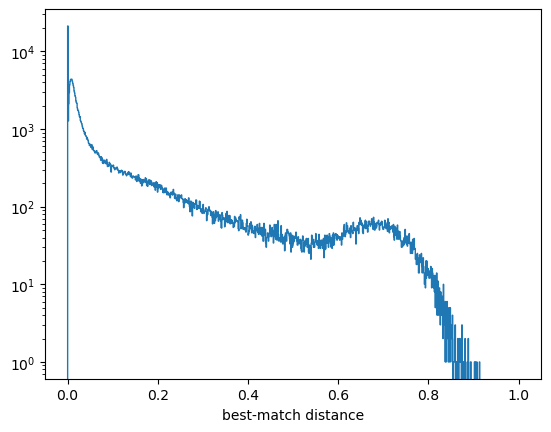

In [392]:
fig, ax = plt.subplots()

ax.hist(subsidiary_nodup["match1_distance"], bins=1000, range=(-1e-5, 1), histtype="step")

ax.set_yscale("log")
ax.set_xlabel("best-match distance")

None

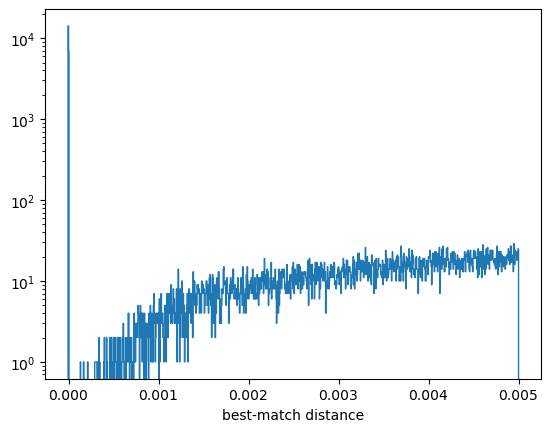

In [393]:
fig, ax = plt.subplots()

ax.hist(subsidiary_nodup["match1_distance"], bins=1000, range=(-1e-5, 5e-3), histtype="step")

ax.set_yscale("log")
ax.set_xlabel("best-match distance")

None

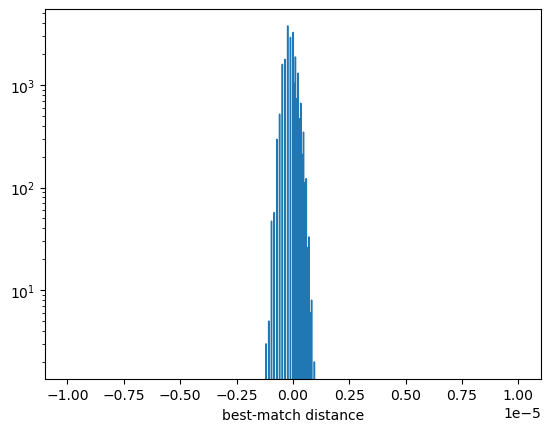

In [394]:
fig, ax = plt.subplots()

ax.hist(subsidiary_nodup["match1_distance"], bins=1000, range=(-1e-5, 1e-5), histtype="step")

ax.set_yscale("log")
ax.set_xlabel("best-match distance")

None

In [400]:
subsidiary_nodup.query("match1_distance < 1e-5")[["name", "match1_name", "match1_cik", "exact_cik"]]

,name,match1_name,match1_cik,exact_cik
3,KEYBANK NATIONAL ASSOC,KEYBANK NATIONAL ASSOC,0000805745,0000805745
22,FEDERAL STREET ACQUISITION CORP,FEDERAL STREET ACQUISITION CORP,0001701821,0001701821
24,AGILITI HEALTH INC,AGILITI HEALTH INC,0000886171,0000886171
41,CARDSTAR INC,CARDSTAR INC,0001487178,0001487178
42,CARDSTAR PUBLISHING LLC,CARDSTAR PUBLISHING LLC,0001690158,0001690158
...,...,...,...,...
200727,AI CAPITAL CORP,AI CAPITAL CORP,0001273753,0001273753
200728,SAI CAPITAL CORP,SAI CAPITAL CORP,0001273750,0001273750
200786,COUNTRYWIDE HOME LOANS INC,COUNTRYWIDE HOME LOANS INC,0000814509,0000814509
200790,COUNTRYWIDE SECURITY CORP,COUNTRYWIDE SECURITY CORP,0000703004,0000703004


In [402]:
best_matches = subsidiary_nodup.query("match1_distance < 1e-5")

np.count_nonzero(best_matches["match1_cik"] == best_matches["exact_cik"]) / len(best_matches)

np.float64(0.9993838862559242)

In [403]:
not_best_matches = subsidiary_nodup.query("match1_distance >= 1e-5")

np.count_nonzero(not_best_matches["match1_cik"] == not_best_matches["exact_cik"]) / len(best_matches)

np.float64(0.0)

In [396]:
for _, row in subsidiary_nodup.query("1e-5 < match1_distance").sort_values("match1_distance").iloc[:20].iterrows():
    print(f"{row['match1_distance']}\n{row['name']}\n{row['match1_name']}\n")

0.00013267993927001953
SANTANDER CONSUMER HOLDING US INC
SANTANDER CONSUMER US HOLDING INC

0.0001703500747680664
OMNICARE PHARMACIES OF PENNSYLVANIA EAST LLC
OMNICARE PHARMACIES OF PENNSYLVANIA WEST LLC

0.00021141767501831055
ORIGEN MANUFACTURED HOUSING CONTRACT TRUST 2005 B
ORIGEN MANUFACTURED HOUSING CONTRACT TRUST 2004 B

0.0002931356430053711
ORIGEN MANUFACTURED HOUSING CONTRACT TRUST 2005 A
ORIGEN MANUFACTURED HOUSING CONTRACT TRUST 2007 A

0.0002969503402709961
BRIDGER AEROSPACE GROUP HOLDING LLC
BRIDGER AEROSPACE GROUP HOLDING INC

0.00030237436294555664
ARAMARK UNIFORM AND CAREER APPAREL INC
ARAMARK UNIFORM AND CAREER APPAREL GROUP INC

0.00030940771102905273
KKR FINANCIAL CLO 2006 2 LTD
KKR FINANCIAL CLO 2006 1 LTD

0.0003147125244140625
KKR FINANCIAL CLO 2011 1 LTD
KKR FINANCIAL CLO 2012 1 LTD

0.00032579898834228516
STEPSTONE NPS PE II LLC
STEPSTONE NPS PE LLC

0.0003370046615600586
FLEXTECH BROADBAND HOLDING LTD
FLEXTECH BROADBAND LTD

0.0003387331962585449
ORIGEN MANUFAC

In [398]:
subsidiary_nodup.to_csv("../subsidiary-name-matches.csv", index=False)